In [1]:
import os, json, time, re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from openai import OpenAI
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
OPENROUTER_API_KEY = os.environ.get("OPENROUTER_API_KEY")
if OPENROUTER_API_KEY is None:
    raise ValueError("OPENROUTER_API_KEY is not set")

In [3]:
client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=OPENROUTER_API_KEY
)

In [4]:
df = pd.read_csv(r"F:\Thesis\project\403-vekalat\structured_questions.csv")
df.head(3)

,question_number,category,question,options
0,1,حقوق مدنی,کدام یک از موارد زیر صحیح است؟,1) با توافق طرفین امکان از بین بردن سبب انفساخ...
1,2,حقوق مدنی,شخص «الف» حین رانندگی با خودرو سواری با شخص «ب...,1) دیه هر دو راننده صرفاً تا میزان دیه کامل و ...
2,3,حقوق مدنی,کدام مورد در خصوص تصرفی که همراه با قصد تملک ب...,1) تصرف در مواردی مملک است حتی اگر همراه با قص...


In [5]:
def to_list(opts):
    if isinstance(opts, list): return opts
    if isinstance(opts, str):
        try:
            v = json.loads(opts)
            if isinstance(v, list): return v
        except Exception: pass
        for sep in ["|","؛",";","/","\\","،","\n"]:
            if sep in opts: return [x.strip() for x in opts.split(sep) if x.strip()]
        return [opts.strip()]
    return [str(opts)]

In [6]:
def render_numeric_options(opts):
    return "\n".join(f"{i+1}) {o}" for i, o in enumerate(opts))

In [7]:
def build_messages(question: str, options_text: str):
    return [
        {
            "role": "system",
            "content": (
                "# Iranian Legal Reasoning Assistant\n"
                "You are an Iranian lawyer and expert in legal reasoning.\n"
                "---\n"
                "## Instructions:\n"
                "- Language of output: Persian (فارسی).\n"
                "- Task: Read the question and numbered options. Think briefly (max 3 short Persian sentences) "
                "and justify ONLY why the correct option is valid under Iranian law.\n"
                "- Provide explicit citation to Iranian legal codes or constitutional principles "
                "(e.g., «ماده 733 ق.م.» or «اصل 173 ق.ا.»).\n"
                "- Do NOT explain why other options are wrong.\n"
                "- Sources: Only Iranian laws and legal principles.\n"
                "---\n"
                "## Output format:\n"
                "- Return a single valid JSON object with exactly these fields:\n"
                '{{"explanation":"...","answer":"X","confidence":YY}}\n'
                "- explanation: Persian, max 3 short sentences, legal justification with citation.\n"
                "- answer: one of \"1\",\"2\",\"3\",\"4\" (or \"1\",\"2\",\"3\" if 3 options).\n"
                "- confidence: must be ONE of {50, 60, 70, 80, 90, 100}, defined as:\n"
                "  50 = Guess with vague reference\n"
                "  60 = Acceptable reasoning but unclear\n"
                "  70 = Clear reasoning with general reference\n"
                "  80 = Strong reasoning with explicit article/principle\n"
                "  90 = Very strong with exact legal text alignment\n"
                "  100 = Direct match with explicit law and clear precedent\n"
                "---\n"
                "⚠️ Important: Output ONLY raw JSON. No markdown, no extra explanation, no repetition of question or options."
            )
        },
        {
            "role": "user",
            "content": f"""سؤال:
{question}

گزینه‌ها (عددی):
{options_text}

Required output:
{{"explanation":"دلیل حقوقی کوتاه","answer":"شماره","confidence":عدد_از_لیست}}"""
        }
    ]


In [8]:
def extract_json(content: str, verbose: bool = False):
    """
    Extract the first valid JSON object or array from input text.
    Handles JSON wrapped in markdown code fences or mixed text.
    """
    if not content or not content.strip():
        if verbose:
            print("⚠️ Content is empty or None")
        return None
    
    content = content.strip()
    
    # Remove markdown fences if present
    if content.startswith("```"):
        lines = content.split("\n")
        if lines[0].strip().startswith("```"):
            lines = lines[1:]
        if lines and lines[-1].strip() == "```":
            lines = lines[:-1]
        content = "\n".join(lines).strip()
    
    # Attempt 1: parse directly
    try:
        return json.loads(content)
    except json.JSONDecodeError as e:
        if verbose:
            print(f"⚠️ Full parse failed: {e}")
    
    # Attempt 2: regex extraction (objects + arrays)
    patterns = [
        r'\{[^{}]*(?:\{[^{}]*\}[^{}]*)*\}',   # JSON object
        r'\[[^\[\]]*(?:\[[^\[\]]*\][^\[\]]*)*\]'  # JSON array
    ]
    
    for pattern in patterns:
        matches = re.finditer(pattern, content, re.DOTALL)
        for match in matches:
            candidate = match.group(0).strip()
            try:
                return json.loads(candidate)
            except json.JSONDecodeError:
                if verbose:
                    print(f"⚠️ Invalid JSON candidate: {candidate[:100]}...")
                continue
    
    if verbose:
        print(f"⚠️ No valid JSON found in content:\n{content[:200]}...")
    return None

In [9]:
VALID_CONFIDENCE = {50, 60, 70, 80, 90, 100}

def call_model(
    model: str, 
    messages, 
    temperature: float = 0.7, 
    max_tokens: int = 512,
    valid_answers: set = {"1", "2", "3", "4"},
    verbose: bool = False
):
    """
    Call LLM and extract structured JSON response.
    
    Args:
        model: Model name
        messages: Chat messages
        temperature: Sampling temperature
        max_tokens: Max output tokens
        valid_answers: Set of valid answer values
        verbose: Print debug info
    
    Returns:
        dict with answer, confidence, explanation, raw, latency_ms, error
    """
    t0 = time.time()
    content = None
    
    try:
        resp = client.chat.completions.create(
            model=model,
            messages=messages,
            temperature=temperature,
            max_tokens=max_tokens,
            timeout=30.0
        )
        latency = int((time.time() - t0) * 1000)
        
        content = resp.choices[0].message.content
        if not content:
            raise ValueError("Empty response from model")
        
        content = content.strip()
        
        if verbose:
            print(f"🔍 Model: {model}")
            print(f"🔍 Raw response (first 200 chars):\n{content[:200]}...")
        
        # استخراج JSON
        data = extract_json(content, verbose=verbose)
        if not data:
            raise ValueError("No valid JSON in response")
        
        # Validate و sanitize answer
        answer = str(data.get("answer", "")).strip()
        if answer not in valid_answers:
            if verbose:
                print(f"⚠️ Invalid answer '{answer}', expected one of {valid_answers}")
            raise ValueError(f"Invalid answer: {answer}")
        
        # Validate و calibrate confidence
        confidence = int(data.get("confidence") or 0)
        if confidence not in VALID_CONFIDENCE:
            original = confidence
            confidence = min(VALID_CONFIDENCE, key=lambda x: abs(x - confidence))
            if verbose:
                print(f"⚠️ Adjusted confidence from {original} to {confidence}")
        
        return {
            "answer": answer,
            "confidence": confidence,
            "explanation": data.get("explanation", ""),
            "raw": content,
            "latency_ms": latency,
            "error": None
        }
        
    except Exception as e:
        latency = int((time.time() - t0) * 1000)
        if verbose:
            print(f"❌ Error: {e}")
            if content:
                print(f"❌ Content was:\n{content[:300]}...")
        
        return {
            "answer": None,
            "confidence": None,
            "explanation": None,
            "raw": content if content else str(e),
            "latency_ms": latency,
            "error": str(e)
        }


In [10]:
def majority_vote(runs, valid_answers={"1", "2", "3", "4"}):
    """
    Determine the winning answer via majority voting.
    
    Args:
        runs: List of dicts with "answer" and "confidence" keys
        valid_answers: Set of valid answer strings
    
    Returns:
        tuple: (winner, conf_mean, conf_vote, votes_map, is_tie)
    """
    # چک اولیه
    if not runs:
        return None, 0.0, 0.0, {}, False
    
    # فیلتر و شمارش رأی‌ها
    votes = Counter([r["answer"] for r in runs if r.get("answer") in valid_answers])
    
    if not votes:
        return None, 0.0, 0.0, {}, False
    
    # پیدا کردن برنده(ها)
    top_count = votes.most_common(1)[0][1]
    tied_answers = [ans for ans, cnt in votes.items() if cnt == top_count]
    
    # مدیریت تساوی با tie-break
    is_tie = len(tied_answers) > 1
    if is_tie:
        # استفاده از میانگین confidence به عنوان tie-breaker
        avg_conf = {}
        for ans in tied_answers:
            confs = [r.get("confidence", 0) for r in runs if r.get("answer") == ans]
            avg_conf[ans] = sum(confs) / len(confs) if confs else 0
        winner = max(avg_conf, key=avg_conf.get)
    else:
        winner = tied_answers[0]
    
    # محاسبه confidence_mean برای برنده
    winner_confs = [r.get("confidence", 0) for r in runs if r.get("answer") == winner]
    conf_mean = round(sum(winner_confs) / len(winner_confs), 1) if winner_confs else 0.0
    
    # محاسبه confidence_vote
    conf_vote = round(votes[winner] / len(runs), 2)
    
    return winner, conf_mean, conf_vote, dict(votes), is_tie


In [11]:
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed

def run_self_consistency_parallel(
    model, 
    df, 
    k=5, 
    temps=[0.6, 0.7, 0.8, 0.6, 0.75], 
    limit=None,
    verbose=False,
    enable_tie_break=True
):
    """
    Run self-consistency with parallel execution.
    
    Args:
        model: Model name
        df: DataFrame with questions
        k: Number of runs per question
        temps: List of temperatures to cycle through
        limit: Max number of questions (None = all)
        verbose: Print debug info
        enable_tie_break: Add extra run if tie detected
    
    Returns:
        pd.DataFrame with results
    """
    rows = []
    errors = []
    
    iterator = tqdm(df.iterrows(), total=len(df), desc=f"SC({model})") if not verbose else df.iterrows()
    
    for idx, row in iterator:
        if limit and idx >= limit:
            break
        
        q_start = time.time()
        
        try:
            qid = row.get("id", idx)
            q = row["question"]
            opts_list = to_list(row["options"])
            options_text = render_numeric_options(opts_list)
            messages = build_messages(q, options_text)
            
            if verbose:
                print(f"\n📝 Q{qid}: {q[:60]}...")
            
            # موازی‌سازی
            runs = []
            with ThreadPoolExecutor(max_workers=min(k, 5)) as executor:
                futures = [
                    executor.submit(call_model, model, messages, temps[i % len(temps)], 512)
                    for i in range(k)
                ]
                for future in as_completed(futures):
                    runs.append(future.result())
            
            # رأی‌گیری
            winner, conf_mean, conf_vote, votes_dict, is_tie = majority_vote(runs)  # ✅ 5 مقدار

            # Tie-break
            if enable_tie_break and winner and conf_vote <= 0.5 and len(votes_dict) > 1:
                if verbose:
                    print(f"   🔄 Tie detected (conf={conf_vote}), running tie-breaker...")
                tie_run = call_model(model, messages, temperature=0.2, max_tokens=512)
                runs.append(tie_run)
                winner, conf_mean, conf_vote, votes_dict, is_tie = majority_vote(runs)

            # ساخت رکورد
            rec = {
                "id": qid,
                "model": model,
                "answer_final": winner,
                "confidence_mean": conf_mean, 
                "confidence_vote": conf_vote,
                "votes_map": json.dumps(votes_dict, ensure_ascii=False), 
                "is_tie": is_tie,
                "latency_avg_ms": round(sum([r["latency_ms"] for r in runs])/len(runs), 1) if runs else 0,
                "total_time_ms": int((time.time() - q_start) * 1000),
            }
            
            # ذخیره per-run (فقط k اولی)
            for i in range(min(k, len(runs))):
                r = runs[i]
                rec[f"answer_run{i+1}"] = r["answer"]
                rec[f"confidence_run{i+1}"] = r["confidence"]
                rec[f"explanation_run{i+1}"] = r["explanation"]
                rec[f"error_run{i+1}"] = r.get("error")
            
            rows.append(rec)
            
        except Exception as e:
            error_msg = f"Error processing Q{idx}: {e}"
            print(f"❌ {error_msg}")
            errors.append({"id": qid if 'qid' in locals() else idx, "error": str(e)})
            continue
    
    # چاپ خلاصه خطاها
    if errors:
        print(f"\n⚠️ {len(errors)} questions had errors")
    
    return pd.DataFrame(rows)


In [12]:
# ================== بخش اجرای اصلی ==================
print("="*70)
print("🚀 Self-Consistency Evaluation - Llama 4 Scout")
print("="*70)
print(f"📂 Dataset size: {len(df)} questions")
print(f"🔄 Runs per question: k=5")
print(f"⏱️  Estimated time: ~{len(df) * 5 * 2 / 60:.1f} minutes (rough estimate)")
print("="*70 + "\n")

start_time = time.time()

try:
    # اجرای self-consistency
    results = run_self_consistency_parallel(
        model="meta-llama/llama-4-scout",
        df=df,
        k=5,
        temps=[0.6, 0.7, 0.8, 0.65, 0.75],
        limit=None,  # None = همه سؤالات
        verbose=True,  # True برای دیدن جزئیات
        enable_tie_break=True  # فعال کردن tie-break
    )
    
    elapsed = time.time() - start_time
    
    # ================== خلاصه نتایج ==================
    print("\n" + "="*70)
    print("✅ Execution Completed Successfully!")
    print("="*70)
    print(f"📊 Processed: {len(results)} questions")
    print(f"⏱️  Total time: {elapsed/60:.1f} minutes ({elapsed:.1f} seconds)")
    print(f"⚡ Avg time per question: {elapsed/len(results):.1f} seconds")
    
    # ================== آمار کلیدی ==================
    print("\n" + "="*70)
    print("📈 Summary Statistics")
    print("="*70)
    
    # confidence_vote آمار
    avg_conf_vote = results['confidence_vote'].mean()
    print(f"   Average confidence_vote: {avg_conf_vote:.3f}")
    print(f"   Median confidence_vote: {results['confidence_vote'].median():.3f}")
    print(f"   Min confidence_vote: {results['confidence_vote'].min():.3f}")
    print(f"   Max confidence_vote: {results['confidence_vote'].max():.3f}")
    
    # confidence_mean آمار (اگه موجود باشه)
    if 'confidence_mean' in results.columns:
        avg_conf_mean = results['confidence_mean'].mean()
        print(f"\n   Average confidence_mean: {avg_conf_mean:.1f}")
        print(f"   Median confidence_mean: {results['confidence_mean'].median():.1f}")
    
    # آمار tie
    if 'is_tie' in results.columns:
        tie_count = results['is_tie'].sum()
        print(f"\n   Questions with tie: {tie_count} ({tie_count/len(results)*100:.1f}%)")
    
    # توزیع confidence_vote
    high_conf = (results['confidence_vote'] >= 0.8).sum()
    medium_conf = ((results['confidence_vote'] >= 0.6) & (results['confidence_vote'] < 0.8)).sum()
    low_conf = (results['confidence_vote'] < 0.6).sum()
    
    print(f"\n   High confidence (≥0.8): {high_conf} ({high_conf/len(results)*100:.1f}%)")
    print(f"   Medium confidence (0.6-0.8): {medium_conf} ({medium_conf/len(results)*100:.1f}%)")
    print(f"   Low confidence (<0.6): {low_conf} ({low_conf/len(results)*100:.1f}%)")
    
    # پاسخ‌های خالی یا خطا
    null_answers = results['answer_final'].isna().sum()
    if null_answers > 0:
        print(f"\n   ⚠️  Questions with no valid answer: {null_answers}")
    
    # توزیع پاسخ‌ها
    print(f"\n   Answer distribution:")
    answer_dist = results['answer_final'].value_counts()
    for ans, count in answer_dist.items():
        print(f"      {ans}: {count} ({count/len(results)*100:.1f}%)")
    
    # latency آمار
    avg_latency = results['latency_avg_ms'].mean()
    print(f"\n   Average latency per run: {avg_latency:.0f}ms")
    
    # total_time آمار (اگه موجود باشه)
    if 'total_time_ms' in results.columns:
        avg_total = results['total_time_ms'].mean()
        print(f"   Average total time per question: {avg_total:.0f}ms")
    
    # ================== ذخیره نتایج ==================
    print("\n" + "="*70)
    print("💾 Saving Results")
    print("="*70)
    
    # ذخیره CSV
    csv_filename = "results_llama4_scout.csv"
    results.to_csv(csv_filename, index=False, encoding='utf-8-sig')
    print(f"   ✅ CSV saved: {csv_filename}")
    
    # ذخیره Excel با دو شیت
    excel_filename = "results_llama4_scout.xlsx"
    with pd.ExcelWriter(excel_filename, engine="openpyxl") as writer:
        # شیت خلاصه - شامل تمام ستون‌های مهم
        summary_cols = ["id", "answer_final", "confidence_vote"]
        
        # اضافه کردن ستون‌های اختیاری اگه موجود باشن
        if 'confidence_mean' in results.columns:
            summary_cols.append("confidence_mean")
        if 'is_tie' in results.columns:
            summary_cols.append("is_tie")
        
        summary_cols.extend(["votes_map", "latency_avg_ms"])
        
        if 'total_time_ms' in results.columns:
            summary_cols.append("total_time_ms")
        
        results[summary_cols].to_excel(writer, sheet_name="Summary", index=False)
        
        # شیت کامل با جزئیات
        results.to_excel(writer, sheet_name="Details", index=False)
    
    print(f"   ✅ Excel saved: {excel_filename}")
    print(f"      - Sheet 'Summary': Key metrics")
    print(f"      - Sheet 'Details': Full per-run data")
    
    # ================== نمایش نمونه نتایج ==================
    print("\n" + "="*70)
    print("📋 Sample Results (First 5 questions)")
    print("="*70)
    
    # ستون‌های نمایش
    display_cols = ["id", "answer_final", "confidence_vote"]
    if 'confidence_mean' in results.columns:
        display_cols.append("confidence_mean")
    if 'is_tie' in results.columns:
        display_cols.append("is_tie")
    display_cols.append("votes_map")
    
    print(results[display_cols].head().to_string(index=False))
    
    # ================== سؤالات کم‌اجماع ==================
    if low_conf > 0:
        print("\n" + "="*70)
        print("⚠️  Low Consensus Questions (confidence_vote < 0.6)")
        print("="*70)
        low_conf_df = results[results['confidence_vote'] < 0.6][display_cols].head(10)
        print(low_conf_df.to_string(index=False))
        print(f"\n   💡 Tip: Review these questions manually for quality check")
    
    # ================== سؤالات با تساوی (اگه موجود باشه) ==================
    if 'is_tie' in results.columns:
        tie_questions = results[results['is_tie'] == True]
        if len(tie_questions) > 0:
            print("\n" + "="*70)
            print("🔄 Questions with Tie-Break Applied")
            print("="*70)
            print(tie_questions[display_cols].head(10).to_string(index=False))
            print(f"\n   💡 {len(tie_questions)} questions required tie-breaking")
    
    print("\n" + "="*70)
    print("🎉 All Done!")
    print("="*70)
    
except KeyboardInterrupt:
    print("\n⚠️  Execution interrupted by user")
    if 'results' in locals() and len(results) > 0:
        print(f"   Partial results available: {len(results)} questions processed")
        results.to_csv("results_partial.csv", index=False)
        print("   💾 Partial results saved to: results_partial.csv")
    
except Exception as e:
    print("\n" + "="*70)
    print("❌ ERROR During Execution")
    print("="*70)
    print(f"   Error type: {type(e).__name__}")
    print(f"   Error message: {str(e)}")
    print("\n   Full traceback:")
    import traceback
    traceback.print_exc()
    
    # ذخیره نتایج جزئی اگر موجود باشد
    if 'results' in locals() and len(results) > 0:
        print(f"\n   💾 Saving partial results ({len(results)} questions)...")
        results.to_csv("results_partial_error.csv", index=False)
        print("   ✅ Saved to: results_partial_error.csv")

finally:
    # تمیزکاری
    if 'start_time' in locals():
        total_elapsed = time.time() - start_time
        print(f"\n⏱️  Total execution time: {total_elapsed/60:.2f} minutes")


🚀 Self-Consistency Evaluation - Llama 4 Scout
📂 Dataset size: 120 questions
🔄 Runs per question: k=5
⏱️  Estimated time: ~20.0 minutes (rough estimate)


📝 Q0: کدام یک از موارد زیر صحیح است؟...

📝 Q1: شخص «الف» حین رانندگی با خودرو سواری با شخص «ب» (موتورسوار) ...

📝 Q2: کدام مورد در خصوص تصرفی که همراه با قصد تملک باشد صحیح است؟...

📝 Q3: شخص «الف» (جراح پلاستیک زیبایی) که تحت پوشش کامل بیمه مسئولی...

📝 Q4: شرط وکالت زن در طلاق در چه قالب هایی قابل تحقق است؟...

📝 Q5: کدام مورد در خصوص تشابه »هبه« و »وصیت تملیکی«، صحیح است؟...

📝 Q6: مسئولیت کدام یک از اشخاص زیر در مقابل متعهدله یا زیان دیده ب...
   🔄 Tie detected (conf=0.4), running tie-breaker...

📝 Q7: در قرارداد فروش مالی شرط می شود که چنانچه ثمن معامله ظرف مدت...

📝 Q8: چنانچه مسئولیت مدنی مبتنی بر تقصیر باشد کدام یک از اشخاص زیر...
   🔄 Tie detected (conf=0.4), running tie-breaker...

📝 Q9: پدر برای اداره اموال فرزندان صغیرش بعد از فوت خود برادرش را ...

📝 Q10: کدام مورد در خصوص تشابه و تفاوت تعلیق در مرحله انعقاد قراردا...

📝 


📊 Generating Visualizations


C:\Users\sazgar\AppData\Local\Temp\ipykernel_19404\2039790875.py:95: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax5.boxplot(answer_conf_data, labels=answer_labels, patch_artist=True,


   ✅ Visualization saved: visualizations_llama4_scout.png


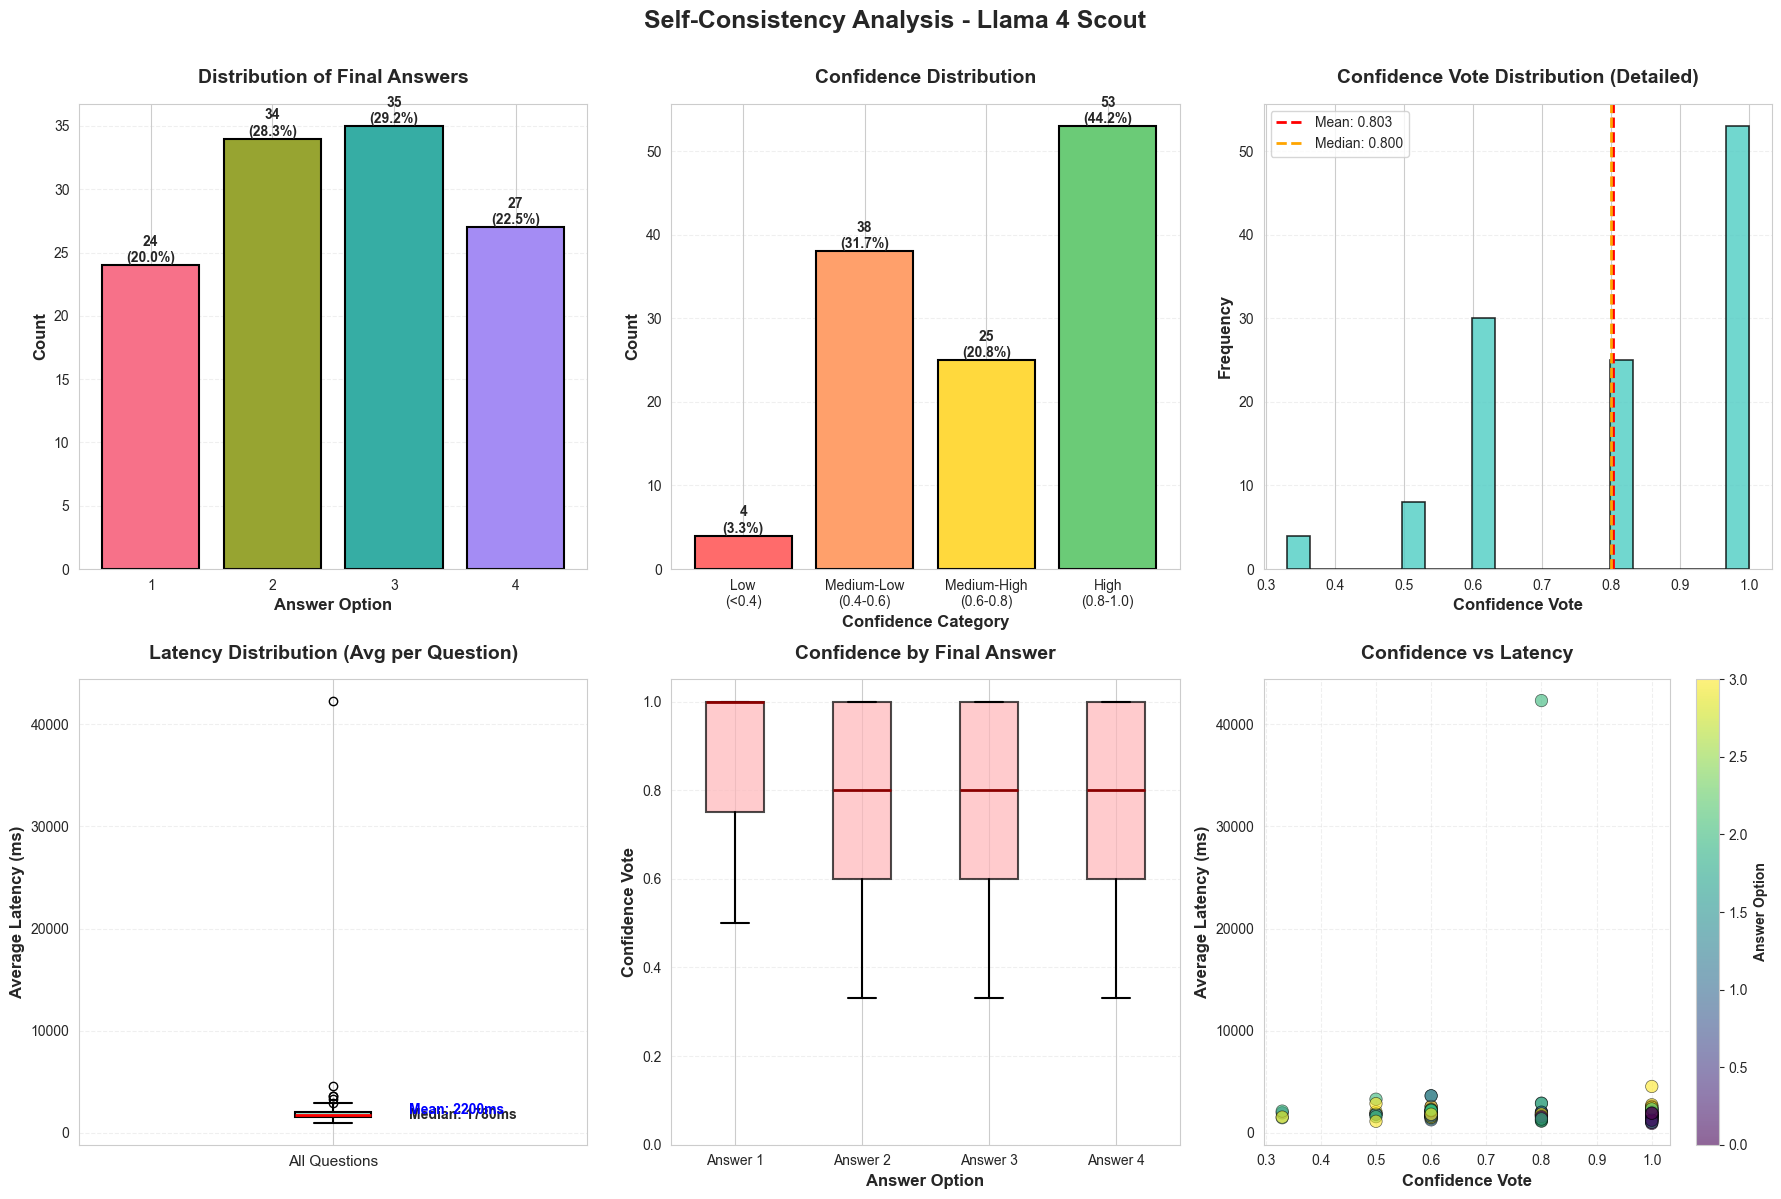


📊 Generating correlation heatmap...
   ✅ Heatmap saved: correlation_heatmap.png


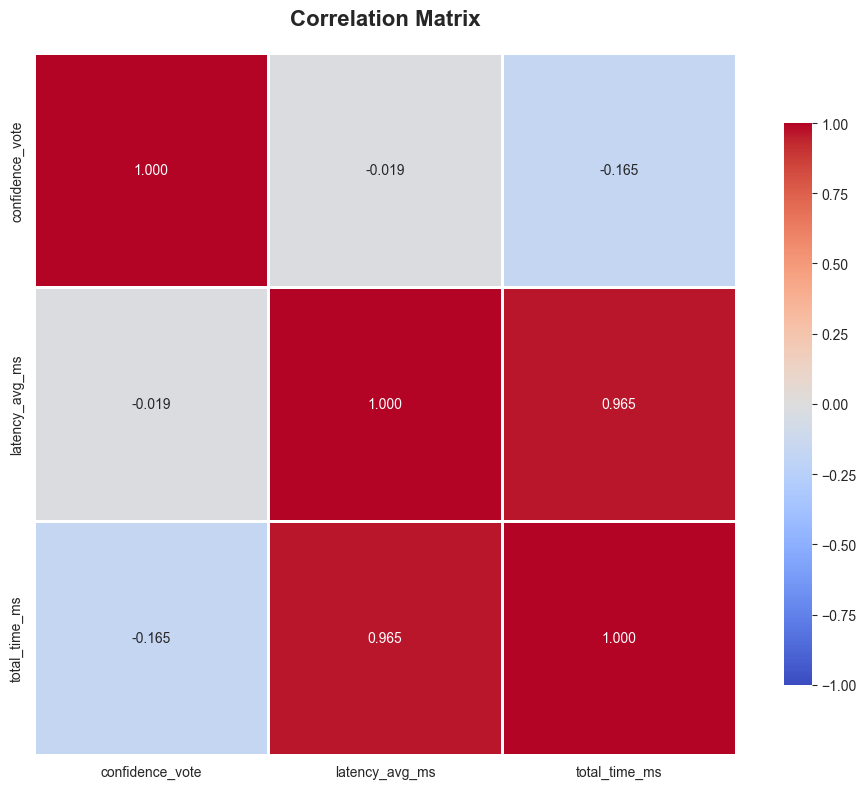


📊 Generating performance timeline...
   ✅ Timeline saved: processing_timeline.png


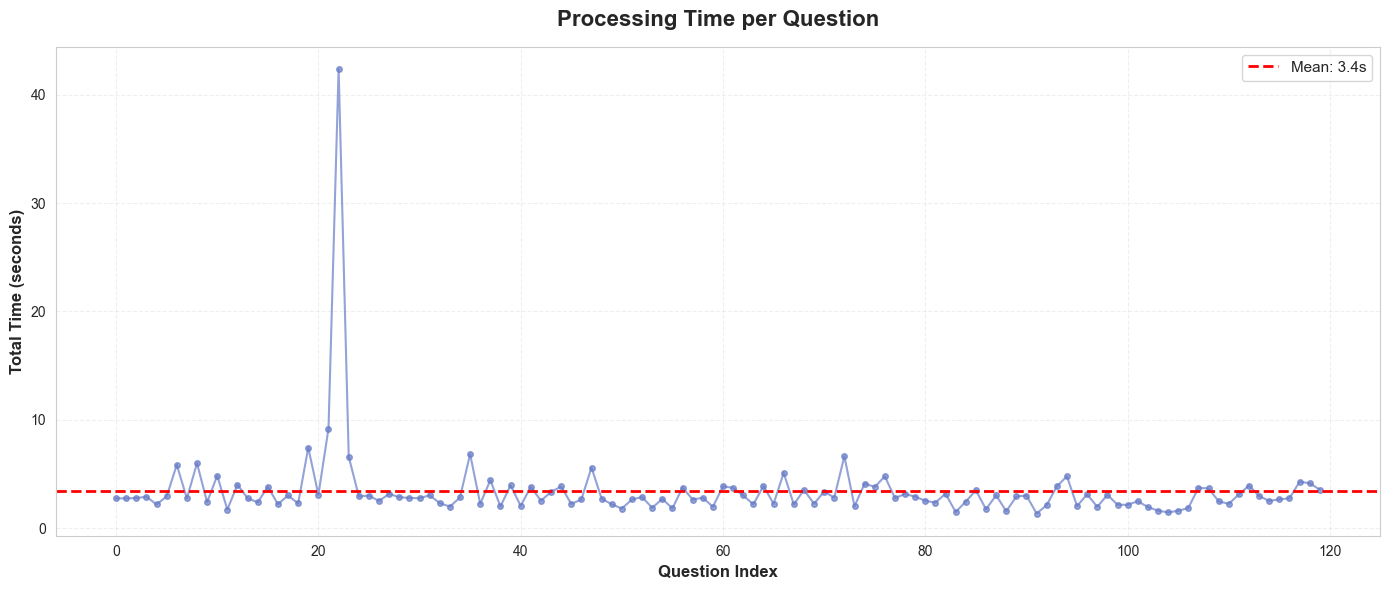


✅ All visualizations generated successfully!


In [13]:
# تنظیمات نمایش فارسی
plt.rcParams['font.family'] = 'Arial'  # یا هر فونت دیگه‌ای که فارسی پشتیبانی کنه
sns.set_style("whitegrid")
sns.set_palette("husl")

# ================== بخش نمودارها ==================
print("\n" + "="*70)
print("📊 Generating Visualizations")
print("="*70)

# ایجاد فیگور بزرگ با چند subplot
fig = plt.figure(figsize=(18, 12))

# ==================== نمودار 1: توزیع پاسخ نهایی ====================
ax1 = plt.subplot(2, 3, 1)
answer_counts = results['answer_final'].value_counts().sort_index()
colors = sns.color_palette("husl", len(answer_counts))
bars = ax1.bar(answer_counts.index.astype(str), answer_counts.values, color=colors, edgecolor='black', linewidth=1.5)

# افزودن درصد روی ستون‌ها
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}\n({height/len(results)*100:.1f}%)',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

ax1.set_title('Distribution of Final Answers', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Answer Option', fontsize=12, fontweight='bold')
ax1.set_ylabel('Count', fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# ==================== نمودار 2: توزیع Confidence ====================
ax2 = plt.subplot(2, 3, 2)
confidence_bins = [0, 0.4, 0.6, 0.8, 1.0]
confidence_labels = ['Low\n(<0.4)', 'Medium-Low\n(0.4-0.6)', 'Medium-High\n(0.6-0.8)', 'High\n(0.8-1.0)']
results['conf_category'] = pd.cut(results['confidence_vote'], bins=confidence_bins, labels=confidence_labels, include_lowest=True)
conf_counts = results['conf_category'].value_counts().sort_index()

colors_conf = ['#FF6B6B', '#FFA06B', '#FFD93D', '#6BCB77']
bars2 = ax2.bar(range(len(conf_counts)), conf_counts.values, color=colors_conf, edgecolor='black', linewidth=1.5)

for i, bar in enumerate(bars2):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}\n({height/len(results)*100:.1f}%)',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2.set_xticks(range(len(conf_counts)))
ax2.set_xticklabels(conf_counts.index, fontsize=10)
ax2.set_title('Confidence Distribution', fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Confidence Category', fontsize=12, fontweight='bold')
ax2.set_ylabel('Count', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3, linestyle='--')

# ==================== نمودار 3: Histogram Confidence ====================
ax3 = plt.subplot(2, 3, 3)
ax3.hist(results['confidence_vote'], bins=20, color='#4ECDC4', edgecolor='black', linewidth=1.2, alpha=0.8)
ax3.axvline(results['confidence_vote'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {results["confidence_vote"].mean():.3f}')
ax3.axvline(results['confidence_vote'].median(), color='orange', linestyle='--', linewidth=2, label=f'Median: {results["confidence_vote"].median():.3f}')

ax3.set_title('Confidence Vote Distribution (Detailed)', fontsize=14, fontweight='bold', pad=15)
ax3.set_xlabel('Confidence Vote', fontsize=12, fontweight='bold')
ax3.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax3.legend(fontsize=10, loc='upper left')
ax3.grid(axis='y', alpha=0.3, linestyle='--')

# ==================== نمودار 4: Boxplot Latency ====================
ax4 = plt.subplot(2, 3, 4)
bp = ax4.boxplot(results['latency_avg_ms'], vert=True, patch_artist=True,
                  boxprops=dict(facecolor='#95E1D3', edgecolor='black', linewidth=1.5),
                  whiskerprops=dict(color='black', linewidth=1.5),
                  capprops=dict(color='black', linewidth=1.5),
                  medianprops=dict(color='red', linewidth=2))

ax4.set_title('Latency Distribution (Avg per Question)', fontsize=14, fontweight='bold', pad=15)
ax4.set_ylabel('Average Latency (ms)', fontsize=12, fontweight='bold')
ax4.set_xticklabels(['All Questions'], fontsize=11)
ax4.grid(axis='y', alpha=0.3, linestyle='--')

# اضافه کردن آمار روی نمودار
median_lat = results['latency_avg_ms'].median()
mean_lat = results['latency_avg_ms'].mean()
ax4.text(1.15, median_lat, f'Median: {median_lat:.0f}ms', fontsize=10, fontweight='bold', va='center')
ax4.text(1.15, mean_lat, f'Mean: {mean_lat:.0f}ms', fontsize=10, fontweight='bold', va='center', color='blue')

# ==================== نمودار 5: Confidence به تفکیک Answer ====================
ax5 = plt.subplot(2, 3, 5)
answer_conf_data = []
answer_labels = []
for ans in sorted(results['answer_final'].dropna().unique()):
    conf_values = results[results['answer_final'] == ans]['confidence_vote']
    answer_conf_data.append(conf_values)
    answer_labels.append(f'Answer {ans}')

bp2 = ax5.boxplot(answer_conf_data, labels=answer_labels, patch_artist=True,
                   boxprops=dict(facecolor='#FFB6B9', alpha=0.7, edgecolor='black', linewidth=1.5),
                   whiskerprops=dict(color='black', linewidth=1.5),
                   capprops=dict(color='black', linewidth=1.5),
                   medianprops=dict(color='darkred', linewidth=2))

ax5.set_title('Confidence by Final Answer', fontsize=14, fontweight='bold', pad=15)
ax5.set_xlabel('Answer Option', fontsize=12, fontweight='bold')
ax5.set_ylabel('Confidence Vote', fontsize=12, fontweight='bold')
ax5.set_ylim([0, 1.05])
ax5.grid(axis='y', alpha=0.3, linestyle='--')

# ==================== نمودار 6: Scatter Confidence vs Latency ====================
ax6 = plt.subplot(2, 3, 6)
scatter = ax6.scatter(results['confidence_vote'], results['latency_avg_ms'], 
                      c=results['answer_final'].astype('category').cat.codes, 
                      cmap='viridis', s=80, alpha=0.6, edgecolors='black', linewidth=0.5)

ax6.set_title('Confidence vs Latency', fontsize=14, fontweight='bold', pad=15)
ax6.set_xlabel('Confidence Vote', fontsize=12, fontweight='bold')
ax6.set_ylabel('Average Latency (ms)', fontsize=12, fontweight='bold')
ax6.grid(alpha=0.3, linestyle='--')

# Colorbar برای تشخیص پاسخ‌ها
cbar = plt.colorbar(scatter, ax=ax6)
cbar.set_label('Answer Option', fontsize=10, fontweight='bold')

# ==================== تنظیمات کلی ====================
plt.suptitle('Self-Consistency Analysis - Llama 4 Scout', 
             fontsize=18, fontweight='bold', y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.99])

# ذخیره نمودار
viz_filename = 'visualizations_llama4_scout.png'
plt.savefig(viz_filename, dpi=300, bbox_inches='tight', facecolor='white')
print(f"   ✅ Visualization saved: {viz_filename}")
plt.show()

# ==================== نمودارهای اضافی (جداگانه) ====================

# نمودار 7: Heatmap همبستگی
print("\n📊 Generating correlation heatmap...")
fig2, ax7 = plt.subplots(figsize=(10, 8))

# ستون‌های عددی برای همبستگی
numeric_cols = ['confidence_vote', 'latency_avg_ms']
if 'total_time_ms' in results.columns:
    numeric_cols.append('total_time_ms')

corr_data = results[numeric_cols].corr()
sns.heatmap(corr_data, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=2, cbar_kws={"shrink": 0.8},
            ax=ax7, vmin=-1, vmax=1)

ax7.set_title('Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
heatmap_filename = 'correlation_heatmap.png'
plt.savefig(heatmap_filename, dpi=300, bbox_inches='tight', facecolor='white')
print(f"   ✅ Heatmap saved: {heatmap_filename}")
plt.show()

# نمودار 8: Timeline پیشرفت (اگه زمان ثبت شده باشه)
if 'total_time_ms' in results.columns:
    print("\n📊 Generating performance timeline...")
    fig3, ax8 = plt.subplots(figsize=(14, 6))
    
    ax8.plot(results.index, results['total_time_ms']/1000, 
             marker='o', linestyle='-', linewidth=1.5, markersize=4, 
             color='#667BC6', alpha=0.7)
    
    ax8.axhline(results['total_time_ms'].mean()/1000, 
                color='red', linestyle='--', linewidth=2, 
                label=f'Mean: {results["total_time_ms"].mean()/1000:.1f}s')
    
    ax8.set_title('Processing Time per Question', fontsize=16, fontweight='bold', pad=15)
    ax8.set_xlabel('Question Index', fontsize=12, fontweight='bold')
    ax8.set_ylabel('Total Time (seconds)', fontsize=12, fontweight='bold')
    ax8.legend(fontsize=11)
    ax8.grid(alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    timeline_filename = 'processing_timeline.png'
    plt.savefig(timeline_filename, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"   ✅ Timeline saved: {timeline_filename}")
    plt.show()

print("\n" + "="*70)
print("✅ All visualizations generated successfully!")
print("="*70)
